In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os

path = os.getenv("DATA_PATH")
df = pd.read_csv(path)
target = "Problem_SKU"
# One-hot encode Storage_Size (drop size_4 as baseline)
size_dummies = pd.get_dummies(df['Storage_Size'], prefix='Size', drop_first=True).astype(int)

# Encode Defect_In_Linked_Receive as 0/1
defect_linked_num = df['Defect_In_Linked_Receive'].astype(int)

# Numeric features (keep standardized)
numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]

feature_cols = numeric_features + list(size_dummies.columns) + ['Defect_In_Linked_Receive']

# Combine all properly encoded features
X = df[numeric_features].copy()
X = pd.concat([X, size_dummies, defect_linked_num], axis=1)
y = df[target]


# =========================
# 3. Fit GMM
# =========================
n_clusters = 3  # try 2, 3, 4, 5 and compare
gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type="full",
    random_state=42
)
gmm.fit(X)

# Hard cluster assignment
df["cluster"] = gmm.predict(X)

# Soft membership probabilities
probs = gmm.predict_proba(X)
for i in range(n_clusters):
    df[f"cluster_prob_{i}"] = probs[:, i]

print(df[["cluster"] + [f"cluster_prob_{i}" for i in range(n_clusters)]].head())

   cluster  cluster_prob_0  cluster_prob_1  cluster_prob_2
0        2        0.007468             0.0    9.925321e-01
1        2        0.020989             0.0    9.790114e-01
2        2        0.056556             0.0    9.434440e-01
3        0        1.000000             0.0    2.450421e-21
4        2        0.007536             0.0    9.924644e-01


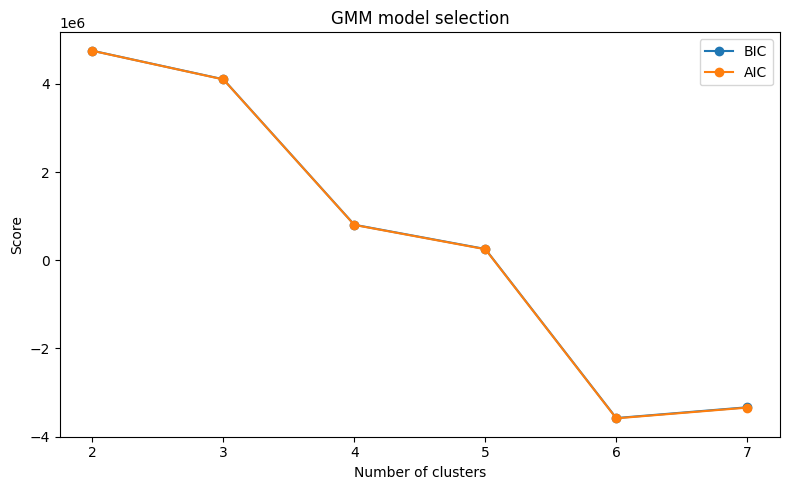

In [2]:
bic_scores = []
aic_scores = []
ks = range(2, 8)

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

plt.figure(figsize=(8, 5))
plt.plot(ks, bic_scores, marker="o", label="BIC")
plt.plot(ks, aic_scores, marker="o", label="AIC")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.title("GMM model selection")
plt.legend()
plt.tight_layout()
plt.show()

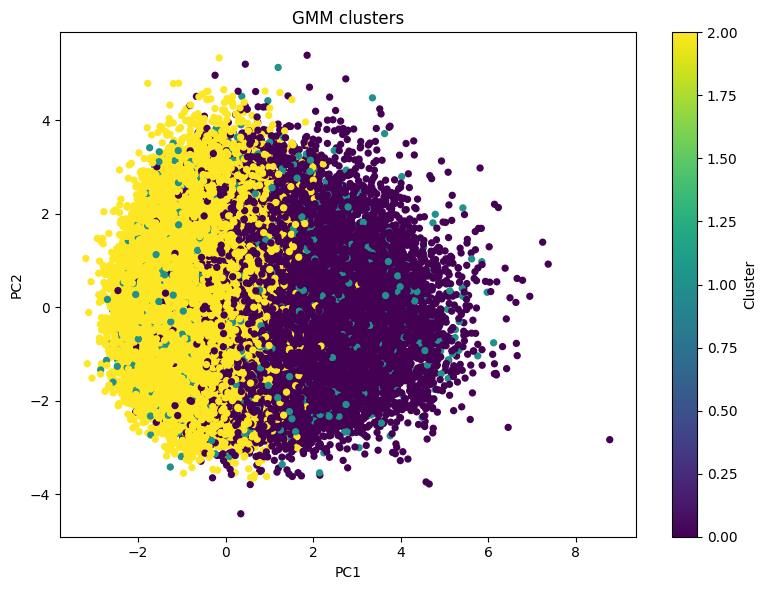

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)   # or X if already scaled

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["cluster"],
    cmap="viridis",
    s=18
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM clusters")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

c:\Users\myfir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


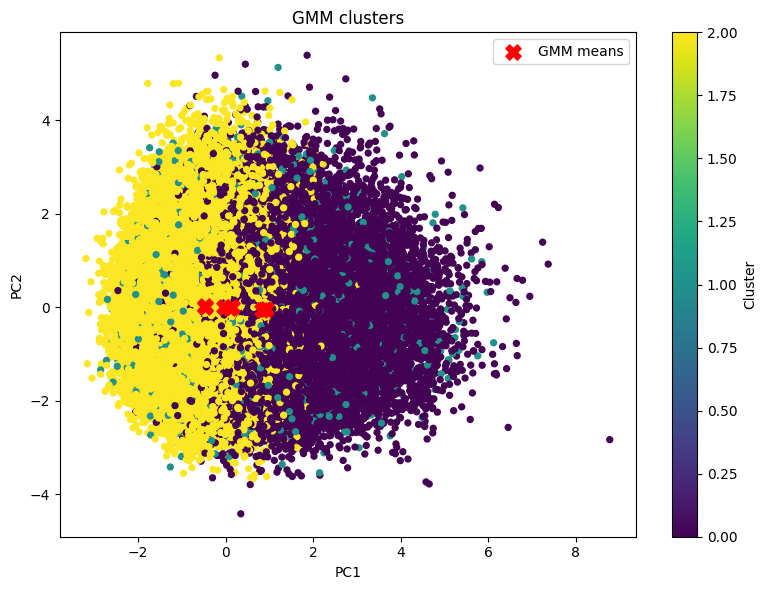

In [7]:
means_2d = pca.transform(gmm.means_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["cluster"], cmap="viridis", s=18)
plt.scatter(means_2d[:, 0], means_2d[:, 1], c="red", s=120, marker="X", label="GMM means")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM clusters")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()